# Causal Mediation Analysis via Activation Patching

**Causal Mediation Analysis**, also known as **Activation Patching**, is a powerful interpretability technique used to understand how neural networks process information. It allows us to identify which layers and components of a model are causally responsible for specific behaviors.

## Core Idea

The key insight is simple: if we want to understand *why* a model produces a certain output, we can:
1. Run the model on a **source prompt** that produces one behavior
2. Run the model on a **target prompt** that produces a different behavior  
3. **Patch** (replace) activations from the source into specific locations in the target
4. Observe how this changes the output—if the target starts behaving like the source, we've found a causally important component

## What You'll Learn

In this tutorial, you will:
- Set up source and target prompts with different expected outputs
- Perform activation patching across all layers of a transformer
- Visualize which layers are most responsible for the behavioral difference
- Investigate specific tokens of interest

---
## Setup

NDIF API KEY

In [1]:
import os

def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

api_key = None
if in_colab():
    from google.colab import userdata
    api_key = userdata.get("NDIF_API_KEY")
else:
    api_key = os.environ.get("NDIF_API_KEY")

if api_key is None:
    os.environ["NDIF_API_KEY"] = input("Enter NDIF API key: ")

Fetch Activation Patching convenience functions

In [2]:
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if in_colab():
    # Git clone and pull only if in Colab
    !git clone https://github.com/AdamBelfki3/activation-patching.git
    !cd activation-patching/ && git pull origin
    !cd ..
    !ls

    import sys
    sys.path.append('/content/activation-patching/')

    # Install required packages in Colab
    !pip install nnsight --no-deps
    !pip install astor python-socketio[client] msgspec

    from IPython.display import clear_output
    clear_output()

In [3]:
import torch
from typing import Union, List, Dict
from nnsight import LanguageModel

### Model Loading

If you set `REMOTE=True` then the model weights will not actually be loaded in your local environment and will instead use the remote NDIF execution.

In [4]:
REMOTE = True

In [24]:
from utils import load_model

model = load_model(input("Enter model key: ") or "openai-community/gpt2-xl", remote=REMOTE)

Enter model key: meta-llama/Llama-3.3-70B-Instruct
Loading model meta-llama/Llama-3.3-70B-Instruct | Remote Execution Mode


---
## Step 1: Define Source and Target Prompts

The foundation of activation patching is having two prompts that elicit *different* behaviors from the model.

**Source Prompt**: The prompt whose activations we will extract (e.g., "Megan Rapinoe plays the sport of" → expects "soccer")

**Target Prompt**: The prompt we will patch into (e.g., "Shaquille O'Neal plays the sport of" → expects "basketball")

By patching source activations into the target, we can see which layers cause the model to "change its mind" from basketball to soccer. This reveals where the model encodes its knowledge about each person's sport.

In [25]:

from utils import tokenize_prompt
from predict import get_next_prediction

DEF_BLOCK = (
    "DEFINITION OF UNCERTAINTY (Second-Moment):\n\n"

    "Uncertainty measures the VARIANCE or SPREAD of possible outcomes, "
    "not the expected value of outcomes.\n\n"

    "EXAMPLES:\n"
    "UNCERTAINTY (variance):\n"
    "- 'Revenue could be anywhere from $50M to $200M' → wide range\n"
    "- 'It depends on whether the regulation passes' → binary outcomes far apart\n"
    "- 'Roll two dice' → 11 possible sums with different probabilities\n\n"

    "NO UNCERTAINTY (zero variance):\n"
    "- 'Revenue will be $100M' → single outcome\n"
    "- 'We will lose $50M due to the tariff' → bad but certain\n"
    "- '2 + 2 = 4' → deterministic\n\n"

    "KEY PRINCIPLE NOT ABOUT SENTIMENT:\n"
    "- 'We expect difficult market conditions' → negative sentiment, but if the difficulty is certain, this is LOW uncertainty\n"
    "- 'Sales will definitely drop 20%' → bad news but NO uncertainty\n"
)


prompt_lead = DEF_BLOCK + "\n\nRespond only one word: Yes or no depending on if the phrase meets the definition of uncertainty:\n\nPhrase:"
prompt_end = "\n\nResponse: "

source_prompt = prompt_lead + "We're worried about gas prices - they could double, or they could stabilize, we just don't have visibility." + prompt_end
source_tokens = tokenize_prompt(source_prompt, model, show=True, title="Source Prompt Tokens")
source_prediction_id = get_next_prediction(
    source_prompt, model, show=True
)

target_prompt = prompt_lead + "We're worried about gas prices because they will definitely increase our costs by 15%." + prompt_end
target_tokens = tokenize_prompt(target_prompt, model, show=True, title="Target Prompt Tokens")
target_prediction_id = get_next_prediction(
    target_prompt, model, show=True
)

                                                                                                                  S
┌┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
└┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴

⬇ Downloading:   0%|          | 0.00/1.71k [00:00<?]

Next Prediction:  Yes | Probability: 0.83


                                                                                                               Targ
┌┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
└┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴

⬇ Downloading:   0%|          | 0.00/1.71k [00:00<?]

Next Prediction:  No | Probability: 0.80


---
## Step 2: Select Patch Positions

Now we need to decide *which token positions* to patch. In transformers, each token position has its own residual stream that gets updated by each layer.

**Key insight**: The name tokens (e.g., "Rapinoe", "O'Neal") are where the model likely stores subject-specific information. By patching at these positions, we can transfer the "identity" from one subject to another.

The visualization below shows which token position we're selecting for patching.

In [26]:
from utils import show_patch_pattern

source_patch = -1#int(input("Enter source patch position: ") or "4")
show_patch_pattern(source_patch, source_tokens, "Source Prompt Tokens")

target_patch = -1#int(input("Enter target patch position: ") or "5")
show_patch_pattern(target_patch, target_tokens, "Target Prompt Tokens")

                                                                                                                  S
┌┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
└┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴

                                                                                                               Targ
┌┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬┬
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
│││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││││
└┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴┴

---
## Step 3: Perform Activation Patching

Now we run the core algorithm. Here's what happens:

1. **First pass (Source)**: Run the source prompt through the model and save the hidden state at our chosen position from every layer
2. **Second pass (Target Clean)**: Run the target prompt normally to get the baseline prediction
3. **Third pass (Target Patched)**: For each layer `i`, run the target prompt but replace the hidden state at position `target_patch` with the source's hidden state from layer `i`

This gives us a "patched" output for each layer, letting us see which layers have the most causal influence on the prediction.

In [27]:
def activation_patching(
    source_prompt: str,
    target_prompt: str,
    source_patch: Union[int, List[int]],
    target_patch: Union[int, List[int]],
    model: LanguageModel
) -> Dict[str, torch.Tensor]:
    """
    Runs activation patching.

    Args:
        source_prompt (str): Input prompt whose activations will be extracted.
        target_prompt (str): Input prompt to receive activation patching.
        source_patch (Union[int, List[int]]): Token position(s) to extract activations from in the source prompt.
        target_patch (Union[int, List[int]]): Token position(s) to patch in the target prompt.
        model (LanguageModel): The instantiated model (nnsight).

    Returns:
        Dict[str, torch.Tensor]: Dictionary containing:
            - "source_logits": Logits for the source prompt after one forward pass ([1, vocab_size])
            - "target_logits_clean": Logits for the target prompt without patching ([1, vocab_size])
            - "target_logits_patched": Dictionary mapping each layer index (str) to patched logits ([1, vocab_size])
    """

    with torch.no_grad():
        with model.session(remote=not model.dispatched):
            with model.trace() as tracer:
                source_activations = list()

                with tracer.invoke(source_prompt)as invoker:
                    for i, layer in enumerate(model.model.layers):
                        hs = layer.output

                        if isinstance(hs, tuple):
                            hs = hs[0]

                        if isinstance(source_patch, int):
                            source_activations.append(hs[0, source_patch, :])
                        else:
                            source_activations.append(hs[0].index_select(dim=0, index=source_patch))

                    source_logits = model.lm_head.output[0][-1].detach().cpu().save()

            with model.trace() as tracer:
                with tracer.invoke(target_prompt):
                    target_logits_clean = model.lm_head.output[0][-1].detach().cpu().save()

                target_logits_patched = dict().save()
                for i in range(len(model.model.layers)):
                    with tracer.invoke(target_prompt):
                        hs = model.model.layers[i].output

                        if isinstance(hs, tuple):
                            hs = hs[0]

                        hs[0, target_patch, :] = source_activations[i] # apply patch

                        target_logits_patched[str(i)] = model.lm_head.output[0][-1].detach().cpu()

    results = {
        "source_logits": source_logits, # [1, vocab_size]
        "target_logits_clean": target_logits_clean, # [1, vocab_size]
        "target_logits_patched": target_logits_patched # {layer_idx: [1, vocab_size]}
    }

    return results

### Run the Patching Experiment

Execute the activation patching with our configured prompts and positions. The results dictionary will contain:
- `source_logits`: The model's predictions for the source prompt
- `target_logits_clean`: The model's predictions for the target prompt (unpatched baseline)
- `target_logits_patched`: A dictionary mapping each layer index to the patched predictions

In [28]:
results = activation_patching(source_prompt, target_prompt, source_patch, target_patch, model)

RemoteException: Traceback (most recent call last):
  File "/u/svcndifuser/ndif-deployment/repos/prod/ndif/src/services/ray/src/ray/deployments/modeling/base.py", line 210, in __call__
    result = await job_task
             ^^^^^^^^^^^^^^
  File "/u/svcndifuser/miniconda3/envs/service/lib/python3.12/asyncio/threads.py", line 25, in to_thread
    return await loop.run_in_executor(None, func_call)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/u/svcndifuser/miniconda3/envs/service/lib/python3.12/concurrent/futures/thread.py", line 59, in run
    result = self.fn(*self.args, **self.kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/u/svcndifuser/miniconda3/envs/service/lib/python3.12/site-packages/ray/util/tracing/tracing_helper.py", line 461, in _resume_span
    return method(self, *_args, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/u/svcndifuser/ndif-deployment/repos/prod/ndif/src/services/ray/src/ray/deployments/modeling/base.py", lin

---
## Step 4: Visualize the Results

Now we can see which layers had the biggest impact! The plot shows how the model's predictions change when we patch each layer.

**Interpreting the plot**:
- **X-axis**: Layer number (0 = early/embedding layers, higher = later/output layers)
- **Y-axis**: The metric we're measuring (rank or probability of specific tokens)
- **Key insight**: Layers where the metric changes dramatically are causally important for the model's behavior

If patching at layer `k` causes the target output to shift toward the source output, then layer `k` contains information that's crucial for distinguishing between the two subjects.

In [ ]:
from visualize import plot_token_metrics_line, AP_Metric

plot_token_metrics_line(
    *results.values(),
    model.tokenizer,
    metric=AP_Metric.RANK,
)

---
## Step 5: Investigate Specific Tokens

The default visualization shows the top predicted tokens. But often we want to track *specific* tokens of interest—like "basketball" and "soccer" in our sports example.

By plotting the **rank** of these tokens across layers, we can see:
- When does "soccer" (source answer) start becoming a plausible answer?
- When does "basketball" (target answer) get suppressed?
- Are there interesting middle layers where both are competitive?

In [ ]:
from utils import get_token_id

plot_token_metrics_line(
    *results.values(),
    model.tokenizer,
    metric=AP_Metric.RANK,
    token_ids=[
        get_token_id(" basketball", model),
        get_token_id(" soccer", model),
        get_token_id(input("Enter token string: ") or " football", model)
    ]
)

### Probability View

While rank shows relative ordering, **probability** shows the actual confidence the model assigns to each token. This can reveal:
- How confident the model is in each prediction
- Whether patching causes probability mass to shift smoothly or abruptly
- Layers where the model is "uncertain" (low probability for all candidates)

Enter token string: 


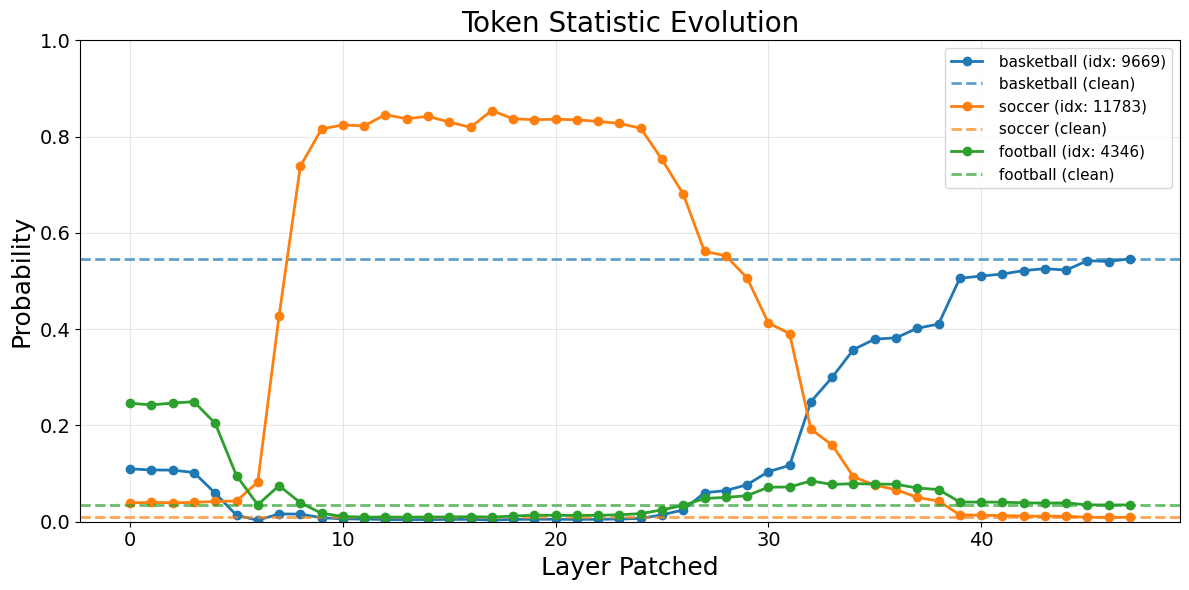

In [18]:
plot_token_metrics_line(
    *results.values(),
    model.tokenizer,
    metric=AP_Metric.PROBABILITY,
    token_ids=[
        get_token_id(" basketball", model),
        get_token_id(" soccer", model),
        get_token_id(input("Enter token string: ") or " football", model)
    ]
)

---
## Conclusion & Next Steps

You've now performed a causal mediation analysis! Here's what you discovered:

**Key Takeaways**:
1. Activation patching reveals *where* in the network specific knowledge is encoded
2. Different layers play different roles—early layers often handle syntax/structure, while later layers encode semantic content
3. The "subject token" positions are often where factual knowledge gets concentrated

**Ideas to Explore**:
- Try different prompt pairs (countries and capitals, people and professions, etc.)
- Patch at different token positions—what happens if you patch the final token?
- Patch multiple positions simultaneously
- Compare results across different model sizes

**Further Reading**:
- [Locating and Editing Factual Associations in GPT](https://rome.baulab.info/) (Meng et al.)
- [Interpretability in the Wild](https://arxiv.org/abs/2211.00593) (Wang et al.)
- [Causal Tracing](https://transformer-circuits.pub/) (Anthropic)